# Simple Linear Regression
## Predicting AQI from Month

**What is Simple Linear Regression?**
- We have ONE input: Month (X)
- We have ONE output: AQI (y)
- We find a line: **y = mx + b**

**Simple Steps:**
1. Load data
2. Prepare X and y
3. Split train/test
4. Train model
5. Make predictions
6. Check accuracy

## Step 1: Load and Check Data

In [1]:
# Step 1: Import libraries (Like CAProject.py)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported (similar to CAProject.py)")

✓ All libraries imported (similar to CAProject.py)


## Step 1: Load Data

In [ ]:
# Load data
df = pd.read_csv('../Data/processed/clean_data.csv')

print(f"Total records: {len(df)}")
print(f"\nFirst 3 rows:")
print(df[['month', 'aqi_value']].head(3))

DATA INFORMATION

Dataset Shape: (425279, 13)

Column Names: ['date', 'state', 'area', 'number_of_monitoring_stations', 'prominent_pollutants', 'aqi_value', 'air_quality_status', 'unit', 'year', 'month', 'day', 'day_of_week', 'quality_level']

Data Types:
date                              object
state                             object
area                              object
number_of_monitoring_stations    float64
prominent_pollutants              object
aqi_value                          int64
air_quality_status                object
unit                              object
year                               int64
month                              int64
day                                int64
day_of_week                       object
quality_level                      int64
dtype: object

First 3 rows:
         date          state      area  number_of_monitoring_stations  \
0  2025-06-19  uttar pradesh      agra                            5.0   
1  2025-06-19      karnataka  bagalk

In [ ]:
# Clean data - remove missing values
df_clean = df[['month', 'aqi_value']].dropna()

print(f"Clean records: {len(df_clean)}")
print(f"Removed: {len(df) - len(df_clean)}")

DATA CLEANING

Missing Values:
date                               0
state                              0
area                               0
number_of_monitoring_stations    141
prominent_pollutants               0
aqi_value                          0
air_quality_status                 0
unit                               0
year                               0
month                              0
day                                0
day_of_week                        0
quality_level                      0
dtype: int64

Original rows: 425279
Clean rows: 425279
Rows removed: 0

Summary Statistics (Clean Data):
           aqi_value          month           year
count  425279.000000  425279.000000  425279.000000
mean      118.664510       6.420150    2021.823151
std        79.492278       3.485458       2.340346
min         3.000000       1.000000    2015.000000
25%        61.000000       3.000000    2020.000000
50%        96.000000       6.000000    2022.000000
75%       152.000000      

## Step 2: Prepare Data

CORRELATION ANALYSIS

Correlation Matrix:
           aqi_value     month      year
aqi_value   1.000000  0.005802 -0.162984
month       0.005802  1.000000 -0.150724
year       -0.162984 -0.150724  1.000000


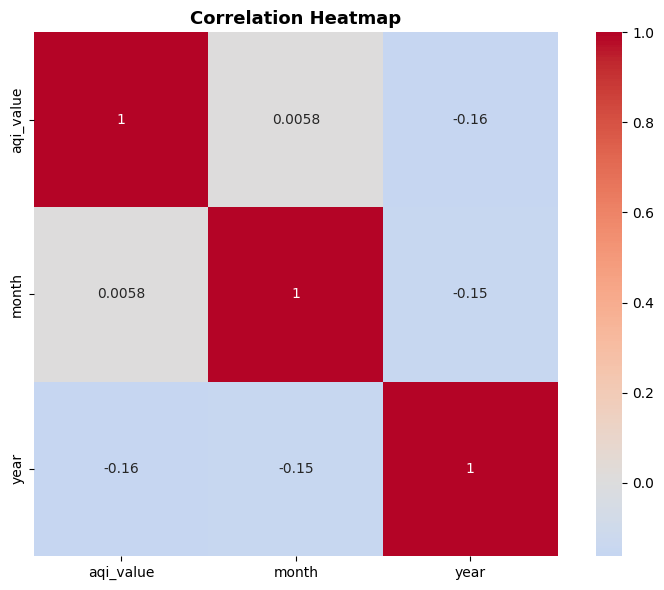


✓ Correlation heatmap displayed


In [ ]:
# Prepare X (input) and y (output)
X = df_clean[['month']].values
y = df_clean['aqi_value'].values

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data: {len(X_train)}")
print(f"Testing data: {len(X_test)}")

## Step 3: Train Model

OUTLIER DETECTION (IQR Method)


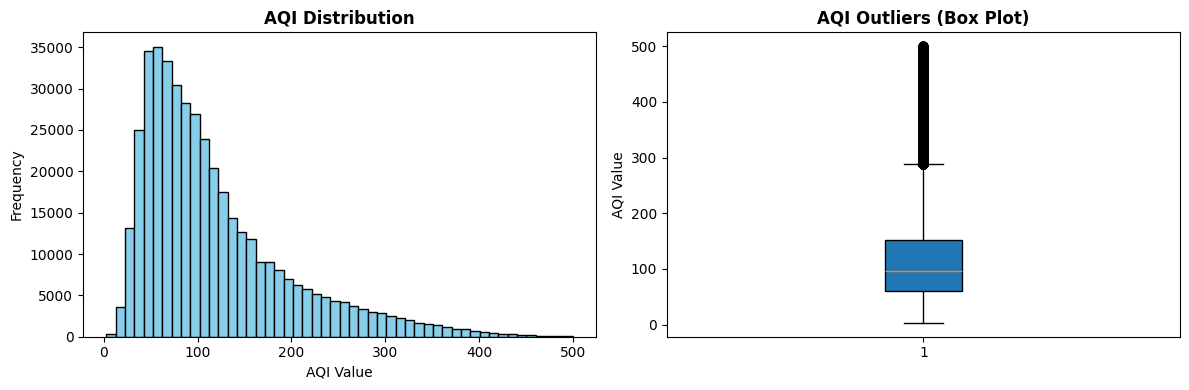


Q1 (25%): 61.00
Q3 (75%): 152.00
IQR: 91.00
Lower Bound: -75.50
Upper Bound: 288.50

Outliers Count: 21400 (5.03%)
Outlier Range: 289.00 to 500.00


In [5]:
# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Get model parameters
slope = model.coef_[0]
intercept = model.intercept_

print("Model trained!")
print(f"\nFormula: AQI = {intercept:.2f} + {slope:.4f} × Month")
print(f"\nSlope: {slope:.4f}")
print(f"Intercept: {intercept:.2f}")

## Step 4: Make Predictions

In [6]:
# Predict on test set
y_pred = model.predict(X_test)

# Show sample predictions
print("Sample Predictions:\n")
for i in range(5):
    print(f"Month {X_test[i][0]:.0f}: Actual={y_test[i]:.1f}, Predicted={y_pred[i]:.1f}")

LINEAR REGRESSION - MONTH → AQI

Training samples: 340223
Testing samples: 85056

✓ Model trained!
Intercept: 117.47
Coefficient: 0.1714

Formula: AQI = 117.47 + 0.1714 × Month


## Step 5: Evaluate Model

In [ ]:
# Calculate accuracy metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance:\n")
print(f"R² Score: {r2:.4f}")
print(f"  → Explains {r2*100:.1f}% of AQI")
print(f"\nMSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"  → Average error: ±{rmse:.2f} AQI")

MODEL EVALUATION

MSE: 6374.4231
RMSE: 79.84
R² Score: -0.0001
  → Explains -0.0% of variance

✓ Sample Predictions:
  Month 1: Actual=72.0, Predicted=117.6
  Month 8: Actual=47.0, Predicted=118.8
  Month 10: Actual=56.0, Predicted=119.2
  Month 10: Actual=72.0, Predicted=119.2
  Month 4: Actual=259.0, Predicted=118.2


## Step 6: Visualize Results

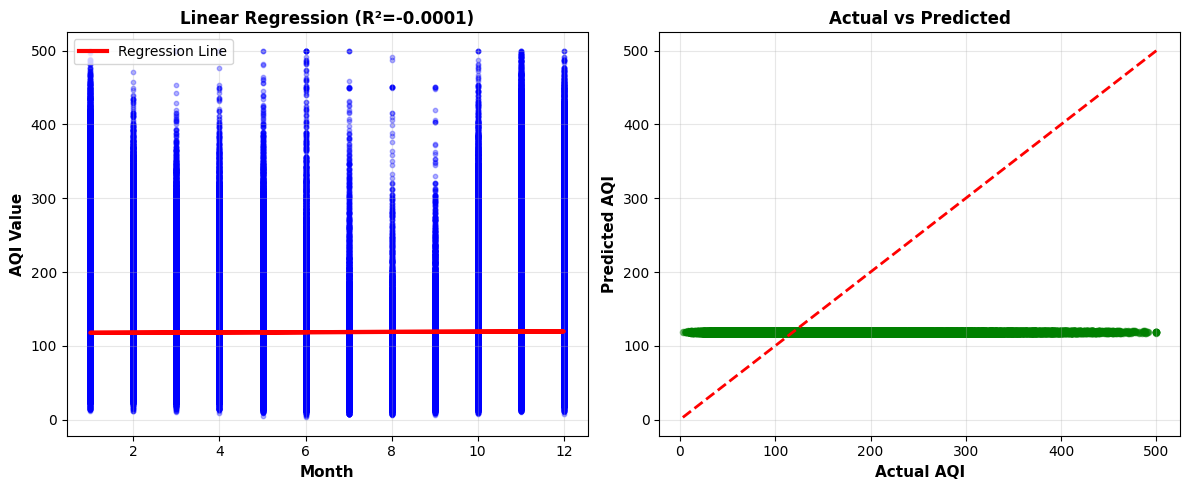

✓ Visualizations displayed


In [8]:
# Plot regression line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.3, s=15, color='blue', label='Data')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')
plt.xlabel('Month', fontsize=11, fontweight='bold')
plt.ylabel('AQI Value', fontsize=11, fontweight='bold')
plt.title(f'Simple Linear Regression (R² = {r2:.4f})', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Plot displayed")

## Step 7: Summary

In [9]:
# Summary
print("="*50)
print("SIMPLE LINEAR REGRESSION SUMMARY")
print("="*50)

print(f"\n✓ Model trained with {len(X_train)} records")
print(f"\n✓ Formula: AQI = {intercept:.2f} + {slope:.4f} × Month")
print(f"\n✓ Accuracy (R²): {r2:.4f}")
print(f"✓ Error (RMSE): {rmse:.2f} AQI points")
print(f"\n✓ Tested on {len(X_test)} records")

print("\n" + "="*50)
print("Ready for evaluation!")
print("="*50)


HYPOTHESIS TESTING - T-TEST

H0: Mean AQI (Jan-Jun) = Mean AQI (Jul-Dec)
Before June Mean: 123.48
After June Mean: 113.45

T-Statistic: 41.1868
P-Value: 0.000000
Significance (α): 0.05

✅ Reject H0: Significant difference!

PREDICTIONS ON NEW DATA

Predicted AQI for specific months:
  Mar: 117.98
  Jun: 118.50
  Sep: 119.01
  Dec: 119.53

FINAL SUMMARY - Like CAProject.py
✓ Rows Cleaned: 0
✓ Outliers Found: 21400 (5.03%)
✓ Model Formula: AQI = 117.47 + 0.1714 × Month
✓ Model R²: -0.0001
✓ RMSE: 79.84
✓ T-Test P-Value: 0.000000
✓ Ready for project evaluation!")
print("="*60)
